In [1]:
## Lab 09. Grafos dirigidos y Ponderados


In [4]:
## Grafos Dirigidos
import networkx as nx
import matplotlib.pyplot as plt

## Creamos el grafo
grafo = nx.DiGraph()
grafo.add_weighted_edges_from([
    ("A","B",5),
    ("A","C",2),
    ("B","D",4),
    ("C","E",5),
    ("C","F",6)
])

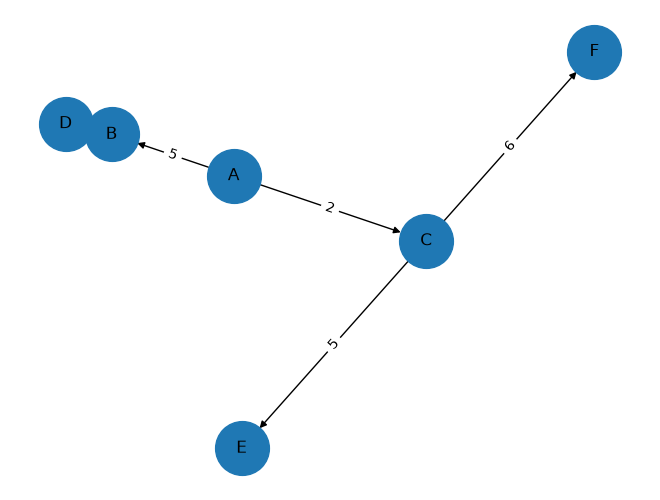

In [5]:
## Imprimimos el grupo
pos = nx.spring_layout(grafo, seed=10)
nx.draw(
            grafo,
            pos,
            with_labels = True,
            node_size = 1500,
            arrows = True
        )
labels = nx.get_edge_attributes(grafo,"weight")
nx.draw_networkx_edge_labels(
                   grafo,
                   pos,
                   edge_labels = labels
               )
plt.show()

In [6]:
# ¿Puedo moverme de A a B?
print (grafo.has_edge ("A","B"))

True


In [7]:
# ¿Puedo moverme de B a A?
print (grafo.has_edge("B","A"))

False


In [8]:
# ¿Puedo mover de A a F?
print (grafo.has_edge("A","F"))

False


In [9]:
# Mostramos las rutas 
rutas = list (
    nx.all_simple_paths(
        grafo,
        source = "A",
        target = "F"
    )
)
#Imprimimos las rutas
for i, ruta in enumerate (rutas, start=1):
    print (f"Ruta{i}:{ruta}")

Ruta1:['A', 'C', 'F']


In [10]:
# Grafo 2
## Creamos el grafo
grafo = nx.DiGraph()
grafo.add_weighted_edges_from([
    ("A","C",7),
    ("A","B",4),
    ("C","D",2),
    ("C","F",5),
    ("B","D",3),
    ("B","E",6),
    ("D","E",2),
    ("D","G",8),
    ("E","G",3),
    ("F","G",4)
])

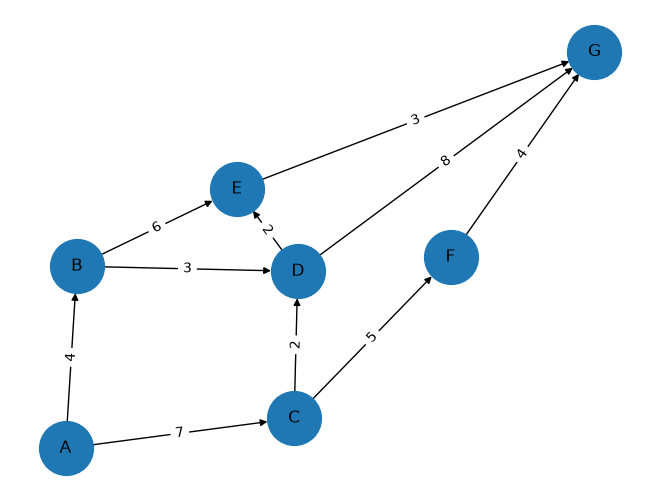

In [11]:
## Imprimimos el grupo
pos = nx.spring_layout(grafo, seed=12)
nx.draw(
        grafo,
        pos,
        with_labels = True,
        node_size = 1500,
        arrows = True
        )
labels = nx.get_edge_attributes(grafo,"weight")
nx.draw_networkx_edge_labels(
                   grafo,
                   pos,
                   edge_labels = labels
               )
plt.show()

In [12]:
# Mostramos las rutas 
rutas = list (
    nx.all_simple_paths(
        grafo,
        source = "A",
        target = "G"
    )
)
#Imprimimos las rutas
for i, ruta in enumerate (rutas, start=1):
    print (f"Ruta{i}:{ruta}")

Ruta1:['A', 'C', 'D', 'E', 'G']
Ruta2:['A', 'C', 'D', 'G']
Ruta3:['A', 'C', 'F', 'G']
Ruta4:['A', 'B', 'D', 'E', 'G']
Ruta5:['A', 'B', 'D', 'G']
Ruta6:['A', 'B', 'E', 'G']


In [13]:
# Calculamos el costo
def costo_ruta (grafo2, ruta):
    costo = 0
    for i in range (len(ruta)-1):
        costo += grafo2 [ruta[i]][ruta[i+1]]["weight"]
        return costo

In [14]:
# Imprimimos el costo
for i, ruta in enumerate (rutas, start = 1):
    costo = costo_ruta(grafo,ruta)
    print (f"Ruta{i}:{ruta}->{costo} unidades")

Ruta1:['A', 'C', 'D', 'E', 'G']->7 unidades
Ruta2:['A', 'C', 'D', 'G']->7 unidades
Ruta3:['A', 'C', 'F', 'G']->7 unidades
Ruta4:['A', 'B', 'D', 'E', 'G']->4 unidades
Ruta5:['A', 'B', 'D', 'G']->4 unidades
Ruta6:['A', 'B', 'E', 'G']->4 unidades


In [23]:
# Elegir la ruta mas corta
costos = [costo_ruta(grafo,ruta)
          for ruta in rutas
         ]
mejor_ruta = costos.index(min(costos))

In [24]:
# Imprimir la mejor ruta

print(f"La mejor ruta es: {mejor_ruta+1}")
print(f"El camino corto es: {costos[mejor_ruta]}")

La mejor ruta es: 4
El camino corto es: 4
